
Loading dataset...
Dataset ready!

========== K-FOLD TRAINING ==========
Fold 1
Accuracy: 0.9058699101004759
Log Loss: 0.23976201600715352
Fold Time: 0.23 sec
Fold 2
Accuracy: 0.9032258064516129
Log Loss: 0.24263184135825502
Fold Time: 0.17 sec
Fold 3
Accuracy: 0.9079851930195664
Log Loss: 0.2339771367866724
Fold Time: 0.17 sec
Fold 4
Accuracy: 0.9058201058201059
Log Loss: 0.2363148447750864
Fold Time: 0.2 sec
Fold 5
Accuracy: 0.9042328042328043
Log Loss: 0.23074295324016666
Fold Time: 0.27 sec

TOTAL K-FOLD TIME: 1.05 sec

========== ITERATIVE TRAINING ==========

Iteration 1
Train Size: 0.5
Accuracy: 0.9113602707848529
Log Loss: 0.22946858745395587
Iteration Time: 0.29 sec

Iteration 2
Train Size: 0.54
Accuracy: 0.8994659856048294
Log Loss: 0.24346075267841694
Iteration Time: 0.16 sec

Iteration 3
Train Size: 0.59
Accuracy: 0.9035245690764085
Log Loss: 0.23981397398980978
Iteration Time: 0.56 sec

Iteration 4
Train Size: 0.63
Accuracy: 0.9120276896452264
Log Loss: 0.2294113185777601

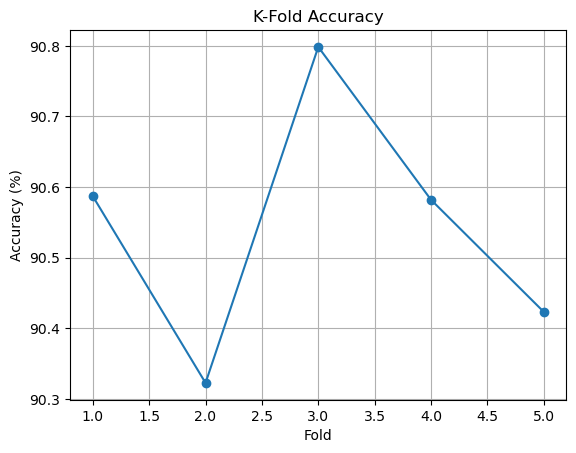

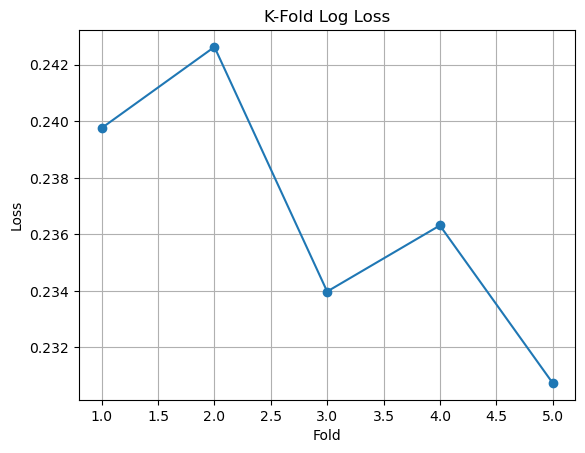

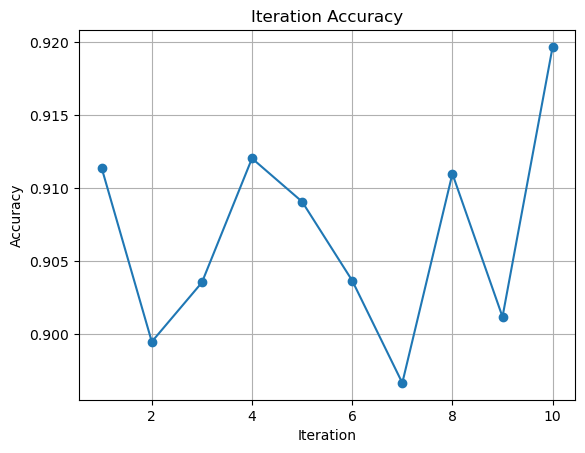

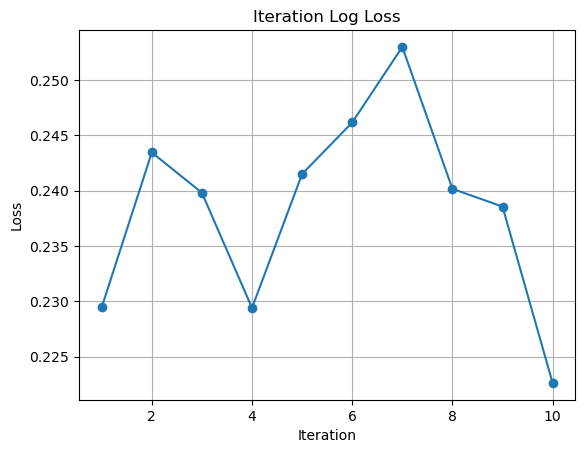


OVERALL EXECUTION TIME: 228.16 sec


In [1]:
import cv2
import os
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    log_loss,
    r2_score
)
from sklearn.linear_model import LogisticRegression

from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy

# ============================================================
# FEATURE EXTRACTION
# ============================================================

def extract_features(img):

    img = cv2.resize(img, (256, 256))

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    s = hsv[:, :, 1]
    _, mask = cv2.threshold(s, 30, 255, cv2.THRESH_BINARY)
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) == 0:
        return None

    cnt = max(contours, key=cv2.contourArea)

    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)
    circularity = (4*np.pi*area)/(perimeter**2+1e-6)

    hull = cv2.convexHull(cnt)
    solidity = area/(cv2.contourArea(hull)+1e-6)

    x,y,w,h = cv2.boundingRect(cnt)
    aspect_ratio = w/h
    extent = area/(w*h+1e-6)

    R,G,B = cv2.split(img)
    hsv_split = cv2.split(hsv)

    stats = []
    for ch in [R,G,B,*hsv_split]:
        m,s = cv2.meanStdDev(ch, mask=mask)
        stats.extend([m[0][0], s[0][0]])

    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    for ch in cv2.split(lab):
        m,s = cv2.meanStdDev(ch, mask=mask)
        stats.extend([m[0][0], s[0][0]])

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_masked = cv2.bitwise_and(gray, gray, mask=mask)

    lap_var = cv2.Laplacian(gray_masked, cv2.CV_64F).var()

    glcm = graycomatrix(gray_masked,[1],[0],256,True,True)
    contrast = graycoprops(glcm,'contrast')[0,0]
    energy = graycoprops(glcm,'energy')[0,0]
    homogeneity = graycoprops(glcm,'homogeneity')[0,0]

    hist = cv2.calcHist([gray_masked],[0],mask,[256],[0,256])
    hist = hist/hist.sum()
    ent = entropy(hist.flatten())

    dark_ratio = np.sum(gray_masked<50)/(np.sum(mask>0)+1e-6)

    return stats + [
        lap_var, contrast, energy, homogeneity,
        ent, area, perimeter, circularity,
        solidity, aspect_ratio, extent, dark_ratio
    ]

# ============================================================
# LOAD DATASET
# ============================================================

dataset_path = r"C:\Users\KIIT0001\Desktop\Model_Fruit_Fressness\archive (4)\train"

data = []
global_start = time.time()

print("\nLoading dataset...")

for folder in os.listdir(dataset_path):

    folder_path = os.path.join(dataset_path, folder)
    if not os.path.isdir(folder_path):
        continue

    label = "Rotten" if "rotten" in folder.lower() else "Fresh"

    for img_name in os.listdir(folder_path):

        img = cv2.imread(os.path.join(folder_path, img_name))
        if img is None:
            continue

        feat = extract_features(img)
        if feat is not None:
            data.append(feat + [label])

df = pd.DataFrame(data)

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

y = LabelEncoder().fit_transform(y)
X = StandardScaler().fit_transform(X)

print("Dataset ready!")

# ============================================================
# K-FOLD TRAINING WITH TIMING
# ============================================================

k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

fold_acc = []
fold_loss = []

print("\n========== K-FOLD TRAINING ==========")

kfold_start = time.time()

for fold,(tr,te) in enumerate(skf.split(X,y),1):

    fold_start = time.time()

    X_train,X_test = X[tr],X[te]
    y_train,y_test = y[tr],y[te]

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train,y_train)

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)

    acc = accuracy_score(y_test,pred)
    loss = log_loss(y_test,prob)

    fold_time = time.time()-fold_start

    fold_acc.append(acc*100)
    fold_loss.append(loss)

    print(f"Fold {fold}")
    print("Accuracy:",acc)
    print("Log Loss:",loss)
    print("Fold Time:",round(fold_time,2),"sec")

kfold_total = time.time()-kfold_start
print("\nTOTAL K-FOLD TIME:",round(kfold_total,2),"sec")

# ============================================================
# ITERATIVE TRAINING
# ============================================================

print("\n========== ITERATIVE TRAINING ==========")

train_sizes = np.linspace(0.5,0.9,10)

iter_acc=[]
iter_loss=[]

iter_start_total = time.time()

for i,size in enumerate(train_sizes,1):

    iter_start=time.time()

    X_train,X_test,y_train,y_test = train_test_split(
        X,y,train_size=size,stratify=y,random_state=42+i
    )

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train,y_train)

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)

    acc = accuracy_score(y_test,pred)
    loss = log_loss(y_test,prob)

    iter_time=time.time()-iter_start

    iter_acc.append(acc)
    iter_loss.append(loss)

    print(f"\nIteration {i}")
    print("Train Size:",round(size,2))
    print("Accuracy:",acc)
    print("Log Loss:",loss)
    print("Iteration Time:",round(iter_time,2),"sec")

iter_total=time.time()-iter_start_total
print("\nTOTAL ITERATION TIME:",round(iter_total,2),"sec")

# ============================================================
# GRAPHS
# ============================================================

plt.figure()
plt.plot(range(1,k+1),fold_acc,marker='o')
plt.title("K-Fold Accuracy")
plt.xlabel("Fold")
plt.ylabel("Accuracy (%)")
plt.grid()
plt.show()

plt.figure()
plt.plot(range(1,k+1),fold_loss,marker='o')
plt.title("K-Fold Log Loss")
plt.xlabel("Fold")
plt.ylabel("Loss")
plt.grid()
plt.show()

plt.figure()
plt.plot(range(1,11),iter_acc,marker='o')
plt.title("Iteration Accuracy")
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.grid()
plt.show()

plt.figure()
plt.plot(range(1,11),iter_loss,marker='o')
plt.title("Iteration Log Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid()
plt.show()

# ============================================================
# TOTAL EXECUTION TIME
# ============================================================

print("\nOVERALL EXECUTION TIME:",
      round(time.time()-global_start,2),"sec")
